In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
data = pd.read_csv("housing.csv")

In [4]:
data

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY
...,...,...,...,...,...,...,...,...,...,...
20635,-121.09,39.48,25.0,1665.0,374.0,845.0,330.0,1.5603,78100.0,INLAND
20636,-121.21,39.49,18.0,697.0,150.0,356.0,114.0,2.5568,77100.0,INLAND
20637,-121.22,39.43,17.0,2254.0,485.0,1007.0,433.0,1.7000,92300.0,INLAND
20638,-121.32,39.43,18.0,1860.0,409.0,741.0,349.0,1.8672,84700.0,INLAND


In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


In [6]:
data.dropna(inplace = True)

In [7]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 20433 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20433 non-null  float64
 1   latitude            20433 non-null  float64
 2   housing_median_age  20433 non-null  float64
 3   total_rooms         20433 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20433 non-null  float64
 6   households          20433 non-null  float64
 7   median_income       20433 non-null  float64
 8   median_house_value  20433 non-null  float64
 9   ocean_proximity     20433 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.7+ MB


In [8]:
from sklearn.model_selection import train_test_split
x = data.drop(['median_house_value'],axis =1)
y=data['median_house_value']

In [9]:
X_train,X_test,y_train,y_test = train_test_split(x,y,test_size = 0.2 )

In [10]:
train_data = X_train.join(y_train)

In [11]:
train_data

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,ocean_proximity,median_house_value
18520,-122.06,37.00,14.0,1547.0,374.0,4731.0,348.0,2.4732,NEAR OCEAN,131300.0
19680,-121.63,39.15,27.0,2991.0,637.0,1419.0,606.0,1.8849,INLAND,73500.0
13883,-117.27,34.45,8.0,6463.0,1095.0,3213.0,1031.0,3.2215,INLAND,108800.0
4763,-118.36,34.04,48.0,1769.0,429.0,993.0,405.0,2.3214,<1H OCEAN,139400.0
2752,-115.40,32.70,19.0,583.0,113.0,531.0,134.0,1.6838,INLAND,95800.0
...,...,...,...,...,...,...,...,...,...,...
2849,-118.96,35.39,23.0,5624.0,1148.0,2842.0,1042.0,3.1297,INLAND,79000.0
3626,-118.43,34.24,35.0,1488.0,293.0,1112.0,288.0,4.4688,<1H OCEAN,182500.0
19704,-121.64,39.11,18.0,3212.0,542.0,1817.0,508.0,3.3793,INLAND,92900.0
15373,-117.25,33.38,17.0,1614.0,431.0,1031.0,389.0,2.0956,<1H OCEAN,134400.0


array([[<Axes: title={'center': 'longitude'}>,
        <Axes: title={'center': 'latitude'}>,
        <Axes: title={'center': 'housing_median_age'}>],
       [<Axes: title={'center': 'total_rooms'}>,
        <Axes: title={'center': 'total_bedrooms'}>,
        <Axes: title={'center': 'population'}>],
       [<Axes: title={'center': 'households'}>,
        <Axes: title={'center': 'median_income'}>,
        <Axes: title={'center': 'median_house_value'}>]], dtype=object)

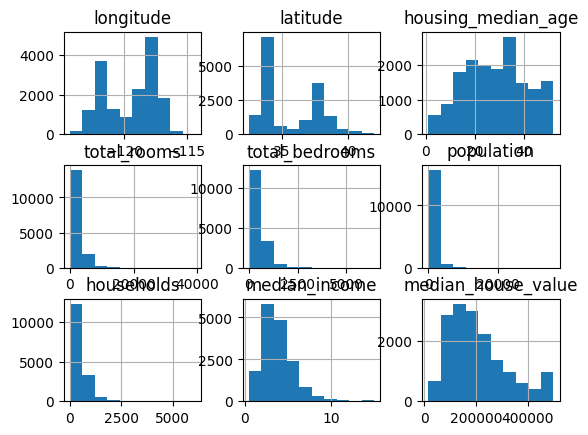

In [12]:
train_data.hist()

In [13]:
train_data_corr = train_data.copy()
train_data_corr = pd.get_dummies(train_data_corr, columns=['ocean_proximity'], drop_first=True)
train_data_corr.corr()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity_INLAND,ocean_proximity_ISLAND,ocean_proximity_NEAR BAY,ocean_proximity_NEAR OCEAN
longitude,1.000000,-0.925879,-0.108872,0.044226,0.069405,0.099966,0.056800,-0.020204,-0.048356,-0.050018,0.010578,-0.465744,0.040208
latitude,-0.925879,1.000000,0.012113,-0.034759,-0.065856,-0.108116,-0.070291,-0.074984,-0.141682,0.343951,-0.018599,0.353666,-0.155281
housing_median_age,-0.108872,0.012113,1.000000,-0.360055,-0.321384,-0.295313,-0.304013,-0.120025,0.103427,-0.235162,0.019280,0.251977,0.024509
total_rooms,0.044226,-0.034759,-0.360055,1.000000,0.930866,0.856708,0.920737,0.197830,0.133776,0.028561,-0.008435,-0.025903,-0.011285
total_bedrooms,0.069405,-0.065856,-0.321384,0.930866,1.000000,0.876583,0.980633,-0.006162,0.050474,-0.005207,-0.004870,-0.023040,-0.003262
population,0.099966,-0.108116,-0.295313,0.856708,0.876583,1.000000,0.905178,0.006485,-0.023032,-0.019336,-0.011557,-0.063292,-0.026697
households,0.056800,-0.070291,-0.304013,0.920737,0.980633,0.905178,1.000000,0.015096,0.065687,-0.035715,-0.010134,-0.015556,-0.002108
median_income,-0.020204,-0.074984,-0.120025,0.197830,-0.006162,0.006485,0.015096,1.000000,0.688423,-0.233654,-0.010427,0.057021,0.032281
median_house_value,-0.048356,-0.141682,0.103427,0.133776,0.050474,-0.023032,0.065687,0.688423,1.000000,-0.482109,0.026270,0.155244,0.148509
ocean_proximity_INLAND,-0.050018,0.343951,-0.235162,0.028561,-0.005207,-0.019336,-0.035715,-0.233654,-0.482109,1.000000,-0.011929,-0.236820,-0.263409


<Axes: >

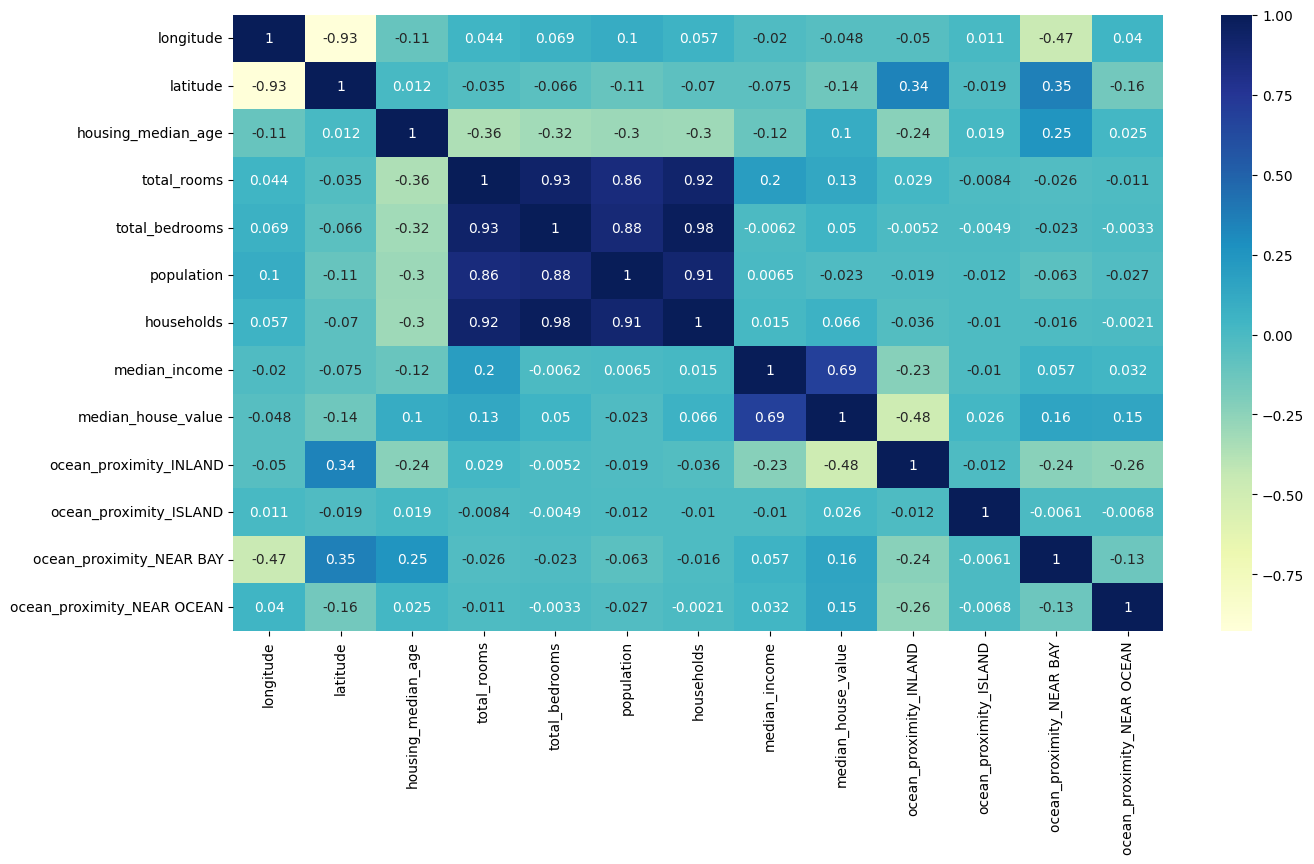

In [14]:
plt.figure(figsize=(15,8))
sns.heatmap(train_data_corr.corr(), annot=True,cmap="YlGnBu")

In [15]:
train_data.ocean_proximity.value_counts()

,count
ocean_proximity,
<1H OCEAN,7271
INLAND,5189
NEAR OCEAN,2122
NEAR BAY,1759
ISLAND,5


<Axes: xlabel='latitude', ylabel='longitude'>

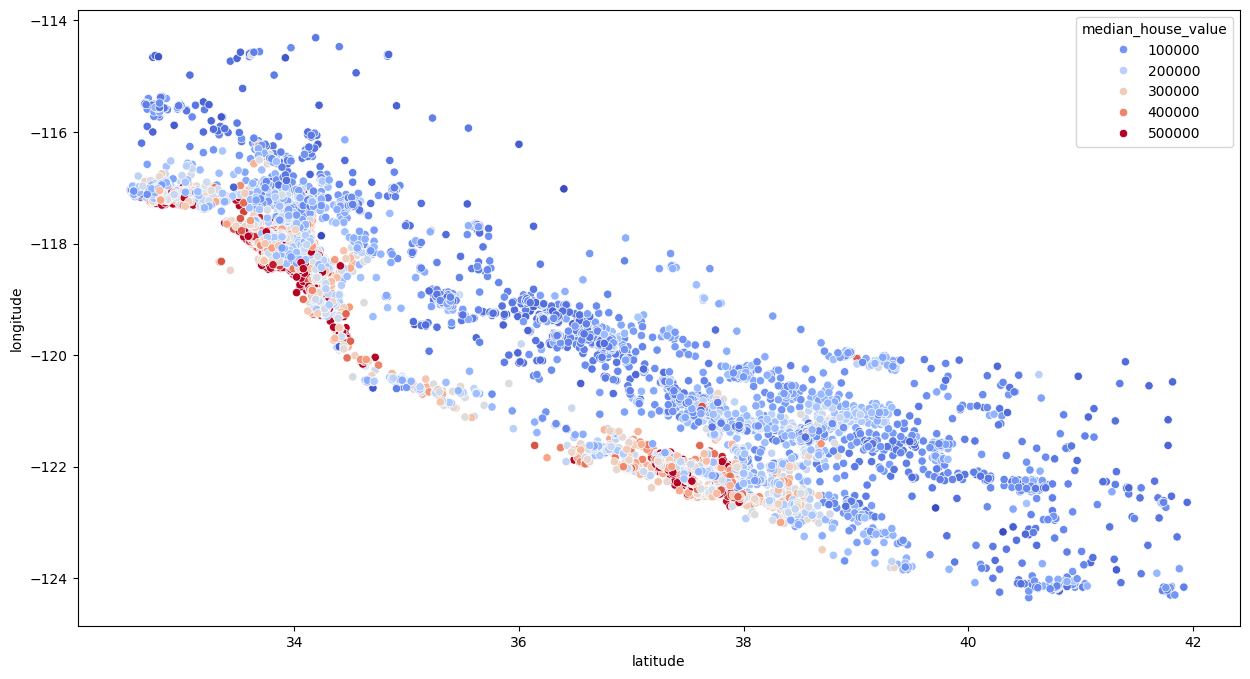

In [16]:
plt.figure(figsize=(15,8))
sns.scatterplot(x="latitude",y="longitude",data = train_data,hue="median_house_value",palette="coolwarm")

In [25]:
from sklearn.linear_model import LinearRegression
import numpy as np

# Apply transformations to train_data (on a copy to avoid modifying the original 'train_data' in place, if it's used elsewhere later)
train_data_transformed = train_data.copy()
train_data_transformed['total_rooms'] = np.log(train_data_transformed['total_rooms']+1)
train_data_transformed['total_bedrooms'] = np.log(train_data_transformed['total_bedrooms']+1)
train_data_transformed['population'] = np.log(train_data_transformed['population']+1)
train_data_transformed['households'] = np.log(train_data_transformed['households']+1)

train_data_transformed['bedroom_ratio'] = train_data_transformed['total_bedrooms']/train_data_transformed['total_rooms']
train_data_transformed['household_rooms'] = train_data_transformed['total_rooms']/train_data_transformed['households']

x_train,y_train = train_data_transformed.drop(['median_house_value'],axis=1),train_data_transformed['median_house_value']

# Apply one-hot encoding to the 'ocean_proximity' column consistently with drop_first=True
x_train = pd.get_dummies(x_train, columns=['ocean_proximity'], drop_first=True)

reg = LinearRegression()
reg.fit(x_train,y_train)

LinearRegression()

In [26]:
test_data = X_test.join(y_test)

test_data['total_rooms'] = np.log(test_data['total_rooms']+1)
test_data['total_bedrooms'] = np.log(test_data['total_bedrooms']+1)
test_data['population'] = np.log(test_data['population']+1)
test_data['households'] = np.log(test_data['households']+1)

# Apply one-hot encoding consistently with drop_first=True
test_data = pd.get_dummies(test_data, columns=['ocean_proximity'], drop_first=True)

test_data['bedroom_ratio'] = test_data['total_bedrooms']/test_data['total_rooms']
test_data['household_rooms'] = test_data['total_rooms']/test_data['households']

In [31]:
X_test,y_test = test_data.drop(['median_house_value'],axis=1),test_data['median_house_value']

# Get the columns from x_train that were used for fitting the model
# (Hardcoding for this fix, in a real scenario you would pass x_train.columns)
x_train_cols = ['longitude', 'latitude', 'housing_median_age', 'total_rooms', 'total_bedrooms',
                'population', 'households', 'median_income', 'bedroom_ratio', 'household_rooms',
                'ocean_proximity_INLAND', 'ocean_proximity_ISLAND', 'ocean_proximity_NEAR BAY',
                'ocean_proximity_NEAR OCEAN']

# Ensure X_test has the same columns as x_train, filling missing with 0 and reordering
X_test = X_test.reindex(columns=x_train_cols, fill_value=0)

In [20]:
train_data

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,ocean_proximity,median_house_value
18520,-122.06,37.00,14.0,1547.0,374.0,4731.0,348.0,2.4732,NEAR OCEAN,131300.0
19680,-121.63,39.15,27.0,2991.0,637.0,1419.0,606.0,1.8849,INLAND,73500.0
13883,-117.27,34.45,8.0,6463.0,1095.0,3213.0,1031.0,3.2215,INLAND,108800.0
4763,-118.36,34.04,48.0,1769.0,429.0,993.0,405.0,2.3214,<1H OCEAN,139400.0
2752,-115.40,32.70,19.0,583.0,113.0,531.0,134.0,1.6838,INLAND,95800.0
...,...,...,...,...,...,...,...,...,...,...
2849,-118.96,35.39,23.0,5624.0,1148.0,2842.0,1042.0,3.1297,INLAND,79000.0
3626,-118.43,34.24,35.0,1488.0,293.0,1112.0,288.0,4.4688,<1H OCEAN,182500.0
19704,-121.64,39.11,18.0,3212.0,542.0,1817.0,508.0,3.3793,INLAND,92900.0
15373,-117.25,33.38,17.0,1614.0,431.0,1031.0,389.0,2.0956,<1H OCEAN,134400.0


In [32]:
reg.score(X_test,y_test)

0.6715023171555403

Random Forest Model

In [39]:
from sklearn.ensemble import RandomForestRegressor
forest = RandomForestRegressor()
forest.fit(x_train,y_train)

RandomForestRegressor()

In [43]:
forest.score(X_test,y_test)

0.8210404576171231

In [44]:
from sklearn.model_selection import GridSearchCV
param_grid={
    "n_estimators" :[3,10,30],
    "max_features":[2,4,6,8]
}
grid_search = GridSearchCV(forest,param_grid,cv=5,scoring="neg_mean_squared_error",return_train_score=True)
grid_search.fit(x_train,y_train)

GridSearchCV(cv=5, estimator=RandomForestRegressor(),
             param_grid={'max_features': [2, 4, 6, 8],
                         'n_estimators': [3, 10, 30]},
             return_train_score=True, scoring='neg_mean_squared_error')

In [45]:
grid_search.best_estimator_

RandomForestRegressor(max_features=8, n_estimators=30)

FileNotFoundError: Cannot find file: yourfile.py

In [47]:
grid_search.best_estimator_

RandomForestRegressor(max_features=8, n_estimators=30)